## CARGAR LAS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
#import sklearn
import dask.dataframe as dd
from pathlib import Path
from dask_sql import Context
import matplotlib.pyplot as plt
#Linea de abajo es para evitar notacion cientifica en los calculos
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
import dask, distributed, dask_sql

print("dask:", dask.__version__)
print("distributed:", distributed.__version__)
print("dask-sql:", dask_sql.__version__)

dask: 2024.5.0
distributed: 2024.5.0
dask-sql: 2024.5.0


## ver en donde estamos trabajando

In [3]:
current_working_directory = Path.cwd()
current_working_directory

WindowsPath('C:/Users/marco')

In [4]:
#Modulo de capital social
df_cs= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de capital social.csv",
                  encoding='utf-8',sep=',',low_memory=False,assume_missing=True)

#Modulo de ventas o ingresos
df_vi= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de ventas o ingresos.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de características del micronegocio
df_cm=dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON\Módulo de características del micronegocio.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de costos, gastos y activos.csv

df_cga= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de costos, gastos y activos.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de emprendimiento.csv
df_me= dd.read_csv("C:/Users/marco/OneDrive/Desktop\Microsimulacion_data/EMICRON/Módulo de emprendimiento.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de identificación.csv
df_mi= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de identificación.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de inclusión financiera.csv
ruta = "C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de inclusión financiera.csv".strip()
df_if = dd.read_csv(ruta, encoding='utf-8', sep=',', low_memory=False,assume_missing=True)


#Módulo de personal ocupado.csv
df_po= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de personal ocupado.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de sitio o ubicación.csv
df_su= dd.read_csv("C:/Users/marco/OneDrive/Desktop\Microsimulacion_data/EMICRON/Módulo de sitio o ubicación.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#Módulo de TIC.csv

ruta = "C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo de TIC.csv".strip()
df_tic = dd.read_csv(ruta, encoding='latin-1', sep=',', low_memory=False,assume_missing=True)

#Módulo personal ocupado (propietario(a)).csv
df_pop= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/Módulo personal ocupado (propietario(a)).csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

#factores de expansión departamentales
df_fex_dep= dd.read_csv("C:/Users/marco/OneDrive/Desktop/Microsimulacion_data/EMICRON/factores_departamental_2024_proy_2018.csv",
                  encoding='latin-1',sep=',',low_memory=False,assume_missing=True)

In [5]:
df_po.head()

,DIRECTORIO,SECUENCIA_PH,SECUENCIA_P,SECUENCIA_ENCUESTA,TIPO,P3077,P3078,P3079,P3080,P3081,P3082,P3083,P3084,P2990,P3085,P3099,CLASE_TE,COD_DEPTO,AREA,F_EXP
0,7627459.000,1.000,1.000,1.000,2.000,NaN,1.000,NaN,2.000,NaN,NaN,NaN,2.000,2.000,240.000,57.000,1.000,68.000,NaN,64.668
1,7627465.000,1.000,2.000,1.000,2.000,NaN,1.000,NaN,2.000,NaN,NaN,NaN,2.000,2.000,24.000,50.000,2.000,76.000,NaN,85.403
2,7627489.000,1.000,4.000,1.000,1.000,2.000,1.000,1175179.000,2.000,NaN,2.000,NaN,2.000,2.000,24.000,25.000,1.000,5.000,5.000,74.923
3,7627489.000,1.000,4.000,2.000,1.000,2.000,1.000,1175179.000,2.000,NaN,2.000,NaN,2.000,2.000,36.000,30.000,1.000,5.000,5.000,74.923
4,7627492.000,1.000,2.000,1.000,2.000,NaN,1.000,NaN,1.000,438058.000,NaN,NaN,1.000,2.000,460.000,60.000,1.000,5.000,5.000,90.956


In [6]:
##total negocios en colombia
print(f"A nivel nacional, la cantidad total de micronegocios es de: {df_mi.compute()['F_EXP'].sum()}")

A nivel nacional, la cantidad total de micronegocios es de: 5297251.556248039


In [7]:
## El valor agregado de los micronocios
df_vi['VALOR_AGREGADO_ANUAL'] = df_vi['VALOR_AGREGADO']*df_vi['F_EXP']*12

In [8]:
print (f"El total del valor agregado de todos lo micronegocios para el año 2024 en colombia fue de: {df_vi['VALOR_AGREGADO_ANUAL'].compute().sum()}")

El total del valor agregado de todos lo micronegocios para el año 2024 en colombia fue de: 86755643636700.19


In [9]:
## revisando la nueva columna creada
df_vi['VALOR_AGREGADO_ANUAL'].compute().head(5)

0    198887306.438
1    828874319.722
2    335722843.329
3   1369994315.576
4    407353417.521
Name: VALOR_AGREGADO_ANUAL, dtype: float64

## <span style="color:green">Ahora vamos a realizar un inner join para obtener una tabla apartir de la informacion de la tabla identifiacion y ingresos </span>

In [10]:
df_mi_vi = dd.merge(df_mi,df_vi, on=['DIRECTORIO', 'SECUENCIA_P','SECUENCIA_ENCUESTA'], how='inner')

In [11]:
df_mi_vi.compute().head(5)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,VENTAS_MES_ANTERIOR,VENTAS_MES_ANIO_ANTERIOR,VENTAS_ANIO_ANTERIOR,VALOR_AGREGADO,INGRESO_MIXTO,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,300000.000,280000.000,3000000.000,276000.000,276000.000,2.000,44.000,NaN,60.051,198887306.438
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,940000.000,850000.000,8000000.000,800000.000,800000.000,2.000,44.000,NaN,86.341,828874319.722
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,300000.000,400000.000,3500000.000,200000.000,200000.000,1.000,68.000,NaN,139.885,335722843.329
3,7627453.000,1.000,2.000,68.000,NaN,1.000,2.000,41.000,ENERO,2.000,...,1500000.000,1380000.000,14000000.000,677000.000,677000.000,1.000,68.000,NaN,168.635,1369994315.576
4,7627456.000,1.000,3.000,68.000,NaN,1.000,1.000,18.000,ENERO,2.000,...,1200000.000,NaN,7000000.000,525000.000,525000.000,1.000,68.000,NaN,64.659,407353417.521


## <span style="color:Red"> Se crea un codigo de clsificaion en el cual se vean las actividades economicas (CIIU) </span>

In [12]:
# Se crea un mapeo departamental
def map_COD_DEPTO_x(value):
    mapping = {
        5: "Antioquia",
        8: "Atlántico",
        11: "Bogotá, D. C.",
        13: "Bolívar",
        15: "Boyacá",
        17: "Caldas",
        18: "Caquetá",
        19: "Cauca",
        20: "Cesar",
        23: "Córdoba",
        25: "Cundinamarca",
        27: "Chocó",
        41: "Huila",
        44: "La Guajira",
        47: "Magdalena",
        50: "Meta",
        52: "Nariño",
        54: "Norte de Santander",
        63: "Quindío",
        66: "Risaralda",
        68: "Santander",
        70: "Sucre",
        73: "Tolima",
        76: "Valle del Cauca",
        88: "Archipiélago de San Andrés, Providencia y Santa Catalina"
    }
    return mapping.get(value, "Otros")

df_mi_vi['map_departa'] = df_mi_vi['COD_DEPTO_x'].apply(map_COD_DEPTO_x, meta=('COD_DEPTO_x', 'object'))


In [13]:
# Se crea un mapeo Ciudades principales y áreas metropolitanas
def map_CUIDAD_PRINCIPAL(value):
    mapping = {
        5: "Medellín AM",
        8: "Barranquilla AM",
        11: "Bogotá",
        13: "Cartagena",
        15: "Tunja",
        17: "Manizales AM",
        18: "Florencia",
        19: "Popayán",
        20: "Valledupar",
        23: "Montería",
        27: "Quibdó",
        41: "Neiva",
        44: "Riohacha",
        47: "Santa Marta",
        50: "Villavicencio",
        52: "Pasto",
        54: "Cúcuta AM",
        63: "Armenia",
        66: "Pereira AM",
        68: "Bucaramanga AM",
        70: "Sincelejo",
        73: "Ibagué",
        76: "Cali AM",
        88: "San Andrés"
    }
    return mapping.get(value, "NO_DATOS")

df_mi_vi['CUIDAD_PRINCIPAL'] = df_mi_vi['AREA_x'].apply(map_CUIDAD_PRINCIPAL, meta=('AREA_x', 'object'))

In [14]:
df_mi_vi[['CUIDAD_PRINCIPAL','AREA_x']].compute().head(5)

,CUIDAD_PRINCIPAL,AREA_x
0,NO_DATOS,NaN
1,NO_DATOS,NaN
2,NO_DATOS,NaN
3,NO_DATOS,NaN
4,NO_DATOS,NaN


In [15]:
def map_grupos12(value):
    mapping = {
        1: 'Agricultura, ganadería, caza, silvicultura y pesca',
        2: 'Minería',
        3: 'Industria manufacturera',
        4: 'Construcción',
        5: 'Comercio y reparación de vehículos automotores y motocicletas',
        6: 'Transporte y almacenamiento',
        7: 'Alojamiento y servicios de comida',
        8: 'Información y comunicaciones',
        9: 'Actividades inmobiliarias, profesionales y servicios administrativos',
        10: 'Educación',
        11: 'Actividades de atención a la salud humana y de asistencia social',
        12: 'Actividades artísticas, de entretenimiento, de recreación y otras actividades de servicios'
    }
    return mapping.get(value, 'Otros')

df_mi_vi['nombre_grupo'] = df_mi_vi['GRUPOS12'].apply(map_grupos12, meta=('GRUPOS12', 'object'))

In [16]:
df_mi_vi[['nombre_grupo','GRUPOS12']].compute().head(5)

,nombre_grupo,GRUPOS12
0,Industria manufacturera,3.000
1,"Agricultura, ganadería, caza, silvicultura y p...",1.000
2,Comercio y reparación de vehículos automotores...,5.000
3,Alojamiento y servicios de comida,7.000
4,Transporte y almacenamiento,6.000


In [17]:
df_mi_vi.compute()

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,VALOR_AGREGADO,INGRESO_MIXTO,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,276000.000,276000.000,2.000,44.000,NaN,60.051,198887306.438,La Guajira,NO_DATOS,Industria manufacturera
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,800000.000,800000.000,2.000,44.000,NaN,86.341,828874319.722,La Guajira,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p..."
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,200000.000,200000.000,1.000,68.000,NaN,139.885,335722843.329,Santander,NO_DATOS,Comercio y reparación de vehículos automotores...
3,7627453.000,1.000,2.000,68.000,NaN,1.000,2.000,41.000,ENERO,2.000,...,677000.000,677000.000,1.000,68.000,NaN,168.635,1369994315.576,Santander,NO_DATOS,Alojamiento y servicios de comida
4,7627456.000,1.000,3.000,68.000,NaN,1.000,1.000,18.000,ENERO,2.000,...,525000.000,525000.000,1.000,68.000,NaN,64.659,407353417.521,Santander,NO_DATOS,Transporte y almacenamiento
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78496,8038070.000,1.000,3.000,13.000,NaN,1.000,1.000,24.000,DICIEMBRE,2.000,...,512000.000,512000.000,1.000,13.000,NaN,362.509,2227256049.446,Bolívar,NO_DATOS,Alojamiento y servicios de comida
78497,8038071.000,1.000,1.000,13.000,NaN,2.000,1.000,30.000,DICIEMBRE,2.000,...,900000.000,900000.000,2.000,13.000,NaN,158.805,1715095252.163,Bolívar,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p..."
78498,8038073.000,1.000,1.000,13.000,NaN,2.000,1.000,66.000,DICIEMBRE,2.000,...,1120000.000,1120000.000,2.000,13.000,NaN,57.451,772143190.238,Bolívar,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p..."
78499,8038074.000,1.000,3.000,13.000,NaN,2.000,1.000,71.000,DICIEMBRE,2.000,...,1400000.000,1400000.000,2.000,13.000,NaN,93.355,1568370481.025,Bolívar,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p..."


## <span style="color:purple"> Se procede a crear la relacion con sql para realizar consultas y operaciones </span>

In [18]:
# Iniciar contexto SQL
context = Context()

# Registrar nuestra tabla para poder consultarla en SQL, cuando tenemos una tabla de dask que queremos consultar
# con SQL la registramos con el comando context.create_table() añadiendo el nombre de los datoos.
context.create_table("df_mi_vi", df_mi_vi)

## <span style="color:purple"> cantidad de negocios por region (colombia, quindio, armenia) </span>

In [19]:
# Calcular el total general ponderado
total_general_df = context.sql("""
    SELECT SUM("F_EXP_y") AS total_general
    FROM df_mi_vi
""").compute()

total_general = float(total_general_df["total_general"].iloc[0])

# Calcular cantidad total y porcentaje por tipo de negocio
TOTAL_NEGOCIOS_COLOMBIA = context.sql(f"""
    SELECT
        "nombre_grupo",
        SUM("F_EXP_y") AS total_ponderado,
        (SUM("F_EXP_y") / {total_general}) * 100 AS porcentaje_participacion
    FROM df_mi_vi
    GROUP BY "nombre_grupo"
    ORDER BY total_ponderado DESC
""")

TOTAL_NEGOCIOS_COLOMBIA.compute()

,nombre_grupo,total_ponderado,porcentaje_participacion
2,Comercio y reparación de vehículos automotores...,1263753.552,23.857
1,"Agricultura, ganadería, caza, silvicultura y p...",1138758.127,21.497
4,Transporte y almacenamiento,628816.756,11.871
0,Industria manufacturera,531987.683,10.043
7,"Actividades artísticas, de entretenimiento, de...",515505.733,9.732
3,Alojamiento y servicios de comida,440223.205,8.310
6,Construcción,300629.310,5.675
5,"Actividades inmobiliarias, profesionales y ser...",276953.331,5.228
8,Actividades de atención a la salud humana y de...,68493.721,1.293
10,Minería,56340.530,1.064


In [20]:
# Total de micronegocios en el Quindío
total_quindio_df = context.sql("""
    SELECT SUM("F_EXP_y") AS total_quindio
    FROM df_mi_vi
    WHERE "COD_DEPTO_x" = 63
""").compute()

total_quindio = float(total_quindio_df["total_quindio"].iloc[0])

# Cálculo de negocios y porcentaje por grupo en el Quindío
TOTAL_NEGOCIOS_QUINDIO = context.sql(f"""
    SELECT
        "nombre_grupo",
        SUM("F_EXP_y") AS total_ponderado,
        (SUM("F_EXP_y") / {total_quindio}) * 100 AS porcentaje_participacion
    FROM df_mi_vi
    WHERE "COD_DEPTO_x" = 63
    GROUP BY "nombre_grupo"
    ORDER BY total_ponderado DESC
""")

TOTAL_NEGOCIOS_QUINDIO.compute()


,nombre_grupo,total_ponderado,porcentaje_participacion
4,Comercio y reparación de vehículos automotores...,12297.769,33.092
2,"Actividades artísticas, de entretenimiento, de...",5903.673,15.886
1,Alojamiento y servicios de comida,5063.944,13.627
8,Transporte y almacenamiento,3321.986,8.939
0,Industria manufacturera,3196.163,8.601
7,"Actividades inmobiliarias, profesionales y ser...",2844.505,7.654
5,Construcción,2302.750,6.197
9,"Agricultura, ganadería, caza, silvicultura y p...",990.703,2.666
3,Actividades de atención a la salud humana y de...,471.451,1.269
6,Información y comunicaciones,444.927,1.197


In [21]:
# Total de micronegocios en Armenia
total_Armenia_df = context.sql("""
    SELECT SUM("F_EXP_y") AS total_Armenia
    FROM df_mi_vi
    WHERE "AREA_x" = 63
""").compute()

total_Armenia_1 = float(total_Armenia_df["total_armenia"].iloc[0])

# Cálculo de negocios y porcentaje por grupo en Armenia
TOTAL_NEGOCIOS_Armenia = context.sql(f"""
    SELECT
        "nombre_grupo",
        SUM("F_EXP_y") AS total_ponderado,
        (SUM("F_EXP_y") / {total_Armenia_1}) * 100 AS porcentaje_participacion
    FROM df_mi_vi
    WHERE "AREA_x" = 63
    GROUP BY "nombre_grupo"
    ORDER BY total_ponderado DESC
""")

TOTAL_NEGOCIOS_Armenia.compute()


,nombre_grupo,total_ponderado,porcentaje_participacion
4,Comercio y reparación de vehículos automotores...,8902.704,33.027
2,"Actividades artísticas, de entretenimiento, de...",4303.775,15.966
1,Alojamiento y servicios de comida,3261.482,12.100
7,"Actividades inmobiliarias, profesionales y ser...",2602.347,9.654
8,Transporte y almacenamiento,2532.719,9.396
0,Industria manufacturera,2120.911,7.868
5,Construcción,1801.158,6.682
6,Información y comunicaciones,444.927,1.651
3,Actividades de atención a la salud humana y de...,401.089,1.488
10,Educación,309.064,1.147


## <span style="color:purple"> ventas o ingresos de los micronegocios </span>

In [22]:
Venta_ingreso_GRUPOS12 = context.sql("""
    SELECT
        "nombre_grupo",
        SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") AS total_ventas_ponderadas,
        SUM("F_EXP_y") AS total_negocios,
        ROUND(
            100.0 * SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") 
            / SUM(SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y")) OVER (),
            2
        ) AS porcentaje_participacion
    FROM df_mi_vi
    GROUP BY "nombre_grupo"
    ORDER BY total_ventas_ponderadas DESC
""")

Venta_ingreso_GRUPOS12.compute()


,nombre_grupo,total_ventas_ponderadas,total_negocios,porcentaje_participacion
2,Comercio y reparación de vehículos automotores...,5814776897526.741,1263753.552,36.500
1,"Agricultura, ganadería, caza, silvicultura y p...",2257047782018.877,1138758.127,14.170
4,Transporte y almacenamiento,1712233701510.343,628816.756,10.750
3,Alojamiento y servicios de comida,1500422632954.076,440223.205,9.420
0,Industria manufacturera,1439738741542.663,531987.683,9.040
5,"Actividades inmobiliarias, profesionales y ser...",1151841783484.333,276953.331,7.230
7,"Actividades artísticas, de entretenimiento, de...",770102513262.736,515505.733,4.830
6,Construcción,685055690653.035,300629.310,4.300
8,Actividades de atención a la salud humana y de...,308155957710.376,68493.721,1.930
9,Información y comunicaciones,134074170821.730,29839.811,0.840


In [23]:
Venta_ingreso_GRUPOS12_quindio = context.sql("""
    SELECT
        "nombre_grupo",
        SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") AS total_ventas_ponderadas,
        SUM("F_EXP_y") AS total_negocios,
        ROUND(
            100.0 * SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") 
            / SUM(SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y")) OVER (),
            2
        ) AS porcentaje_participacion
    FROM df_mi_vi
    WHERE "COD_DEPTO_x" = 63
    GROUP BY "nombre_grupo"
    ORDER BY total_ventas_ponderadas DESC
""")

Venta_ingreso_GRUPOS12_quindio.compute()

,nombre_grupo,total_ventas_ponderadas,total_negocios,porcentaje_participacion
4,Comercio y reparación de vehículos automotores...,80969280898.666,12297.769,55.010
1,Alojamiento y servicios de comida,16785051542.585,5063.944,11.400
8,Transporte y almacenamiento,9971146257.515,3321.986,6.770
0,Industria manufacturera,9608949022.351,3196.163,6.530
7,"Actividades inmobiliarias, profesionales y ser...",8624796112.205,2844.505,5.860
2,"Actividades artísticas, de entretenimiento, de...",7917407523.754,5903.673,5.380
5,Construcción,6257701626.671,2302.750,4.250
9,"Agricultura, ganadería, caza, silvicultura y p...",3545113020.315,990.703,2.410
3,Actividades de atención a la salud humana y de...,1576948859.203,471.451,1.070
6,Información y comunicaciones,1510893718.262,444.927,1.030


In [24]:
Venta_ingreso_GRUPOS12_armenia = context.sql("""
    SELECT
        "nombre_grupo",
        SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") AS total_ventas_ponderadas,
        SUM("F_EXP_y") AS total_negocios,
        ROUND(
            100.0 * SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y") 
            / SUM(SUM("VENTAS_MES_ANTERIOR" * "F_EXP_y")) OVER (),
            2
        ) AS porcentaje_participacion
    FROM df_mi_vi
    WHERE "AREA_x" = 63 
    GROUP BY "nombre_grupo"
    ORDER BY total_ventas_ponderadas DESC
""")

Venta_ingreso_GRUPOS12_armenia.compute()

,nombre_grupo,total_ventas_ponderadas,total_negocios,porcentaje_participacion
4,Comercio y reparación de vehículos automotores...,40808397388.150,8902.704,46.670
1,Alojamiento y servicios de comida,10726015363.988,3261.482,12.270
8,Transporte y almacenamiento,7821112753.267,2532.719,8.940
7,"Actividades inmobiliarias, profesionales y ser...",7759208791.393,2602.347,8.870
0,Industria manufacturera,6493105177.634,2120.911,7.430
2,"Actividades artísticas, de entretenimiento, de...",5896859345.509,4303.775,6.740
5,Construcción,3372055673.500,1801.158,3.860
6,Información y comunicaciones,1510893718.262,444.927,1.730
9,"Agricultura, ganadería, caza, silvicultura y p...",1504360429.715,260.372,1.720
3,Actividades de atención a la salud humana y de...,1129235211.916,401.089,1.290


## <span style="color:purple"> % del valor agregado de los micronegocios por grupo A NIVEL NACIONAL </span>

In [25]:
# 1️⃣ Crear la tabla con el total global
context.create_table("total_valor_agregado", context.sql("""
    SELECT SUM("VALOR_AGREGADO") AS TOTAL_VALOR_AGREGADO FROM df_mi_vi
"""))

# 2️⃣ Hacer el join para sacar el porcentaje
P_N_CIIU = context.sql("""
    SELECT
        t1."nombre_grupo",
        SUM(t1."VALOR_AGREGADO") AS VALOR_AGREGADO_POR_CIIU,
        (SUM(t1."VALOR_AGREGADO") / t2.TOTAL_VALOR_AGREGADO) * 100 AS PORCENTAJE_VALOR_AGREGADO
    FROM df_mi_vi AS t1
    CROSS JOIN total_valor_agregado AS t2
    GROUP BY t1."nombre_grupo", t2.TOTAL_VALOR_AGREGADO
    ORDER BY 2 desc
""")

P_N_CIIU.compute()

,nombre_grupo,valor_agregado_por_ciiu,porcentaje_valor_agregado
2,Comercio y reparación de vehículos automotores...,28841344081.000,28.546
4,Transporte y almacenamiento,12325412464.000,12.199
5,"Actividades inmobiliarias, profesionales y ser...",10840249915.000,10.729
1,"Agricultura, ganadería, caza, silvicultura y p...",10783533191.000,10.673
0,Industria manufacturera,9693207080.000,9.594
3,Alojamiento y servicios de comida,9402348731.000,9.306
7,"Actividades artísticas, de entretenimiento, de...",7371064332.000,7.296
6,Construcción,7218293550.000,7.144
8,Actividades de atención a la salud humana y de...,2425546001.000,2.401
9,Información y comunicaciones,920377518.000,0.911


## <span style="color:purple"> Total micronegocios por actividad </span>

In [26]:
df_mi_vi.compute().head(2)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,VALOR_AGREGADO,INGRESO_MIXTO,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,276000.000,276000.000,2.000,44.000,NaN,60.051,198887306.438,La Guajira,NO_DATOS,Industria manufacturera
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,800000.000,800000.000,2.000,44.000,NaN,86.341,828874319.722,La Guajira,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p..."


In [27]:
Total_nacionla = df_mi_vi["F_EXP_y"].sum().compute()
print (f"El total nacional de micronegocios en el pais es de {Total_nacionla}")

El total nacional de micronegocios en el pais es de 5297251.556248039


In [28]:
Total_negocios = context.sql ('''
    SELECT
        SUM("F_EXP_y") as Total_negocios,
        "nombre_grupo"
    FROM df_mi_vi
   GROUP BY "nombre_grupo"
    ORDER BY 2
''')
Total_negocios.compute()



,total_negocios,nombre_grupo
7,515505.733,"Actividades artísticas, de entretenimiento, de..."
8,68493.721,Actividades de atención a la salud humana y de...
5,276953.331,"Actividades inmobiliarias, profesionales y ser..."
1,1138758.127,"Agricultura, ganadería, caza, silvicultura y p..."
3,440223.205,Alojamiento y servicios de comida
2,1263753.552,Comercio y reparación de vehículos automotores...
6,300629.310,Construcción
11,45868.174,Educación
0,531987.683,Industria manufacturera
9,29839.811,Información y comunicaciones


In [29]:
## mostrando resultado como porcentaje
context.create_table("Total_negocios",Total_negocios)

Total_negocios_por_sector = context.sql ('''

        SELECT
        ("total_negocios"/5188402.435524806)*100 as Porcentaje_negocios_por_sector, "nombre_grupo"
        FROM Total_negocios
        ORDER BY 1 desc

''')
Total_negocios_por_sector.compute()

,porcentaje_negocios_por_sector,nombre_grupo
2,24.357,Comercio y reparación de vehículos automotores...
1,21.948,"Agricultura, ganadería, caza, silvicultura y p..."
4,12.120,Transporte y almacenamiento
0,10.253,Industria manufacturera
7,9.936,"Actividades artísticas, de entretenimiento, de..."
3,8.485,Alojamiento y servicios de comida
6,5.794,Construcción
5,5.338,"Actividades inmobiliarias, profesionales y ser..."
8,1.320,Actividades de atención a la salud humana y de...
10,1.086,Minería


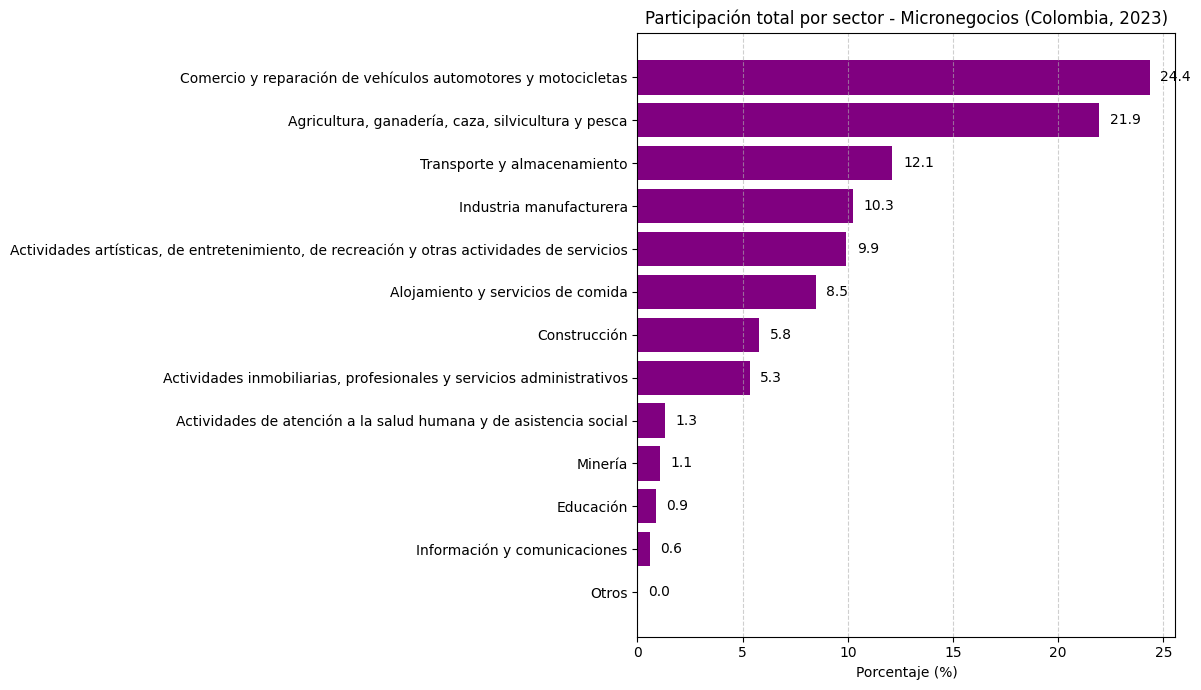

In [30]:
# Asegúrate de que tienes el DataFrame
df_Total_negocios_por_sector = Total_negocios_por_sector.compute()

# Limpiar y ordenar datos
df_Total_negocios_por_sector["porcentaje_negocios_por_sector"] = pd.to_numeric(
    df_Total_negocios_por_sector["porcentaje_negocios_por_sector"], errors="coerce"
).fillna(0)

df_Total_negocios_por_sector = df_Total_negocios_por_sector.sort_values(
    by="porcentaje_negocios_por_sector", ascending=True  # Para barra horizontal con orden de menor a mayor
)

# Graficar
plt.figure(figsize=(12, 7))
bars = plt.barh(
    df_Total_negocios_por_sector["nombre_grupo"],
    df_Total_negocios_por_sector["porcentaje_negocios_por_sector"],
    color="purple"
)

# Agregar etiquetas al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2, f"{width:.1f}", va='center', fontsize=10)

# Configurar gráfico
plt.xlabel("Porcentaje (%)")
plt.title("Participación total por sector - Micronegocios (Colombia, 2023)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

# Mostrar
plt.show()

<div style="text-align: center; color: blue; font-size: 27px; line-height: 1.5;">  Descriptivos de los Micronegocios segun situacion en el empleo del propietario(a)</div>

## creando un mapa donde nos indique donde estan los negocios (Cabeceras municipales, Centros poblados y rural disperso)

In [31]:
def map_zona_negocio(value):
    mapping = {
        1 : 'Cabeceras Municipales',
        2 : 'Centros poblados y rural disperso',
    }
    return mapping.get(value, "NO_HAY_UNA_MONDA")
df_mi_vi['map_ubi'] = df_mi_vi['CLASE_TE_x'].apply(map_zona_negocio, meta=('CLASE_TE_x', 'object'))

                                                        df_mi_vi.compute().head(5)

In [32]:
df_mi_vi[['CLASE_TE_x','map_ubi']].compute()

,CLASE_TE_x,map_ubi
0,2.000,Centros poblados y rural disperso
1,2.000,Centros poblados y rural disperso
2,1.000,Cabeceras Municipales
3,1.000,Cabeceras Municipales
4,1.000,Cabeceras Municipales
...,...,...
78496,1.000,Cabeceras Municipales
78497,2.000,Centros poblados y rural disperso
78498,2.000,Centros poblados y rural disperso
78499,2.000,Centros poblados y rural disperso


<div style="text-align: center; color: green; font-size: 27px; line-height: 1.5;"> Se reviza que si es = 1: Patrón o empleador(a)
2: Trabajador(a) por cuenta propia </div>

In [33]:
def map_P3033(value):
    mapping = {
        1 : 'Patrón o empleador(a)',
        2 : 'Trabajador(a) por cuenta propia',
    }
    return mapping.get(value, "NO_HAY_UNA_MONDA")
df_mi_vi['clas_P3033'] = df_mi_vi['P3033'].apply(map_P3033, meta=('P3033', 'object'))

In [34]:
df_mi_vi[["clas_P3033","P3033"]].compute()

,clas_P3033,P3033
0,Trabajador(a) por cuenta propia,2.000
1,Trabajador(a) por cuenta propia,2.000
2,Trabajador(a) por cuenta propia,2.000
3,Trabajador(a) por cuenta propia,2.000
4,Trabajador(a) por cuenta propia,2.000
...,...,...
78496,Trabajador(a) por cuenta propia,2.000
78497,Trabajador(a) por cuenta propia,2.000
78498,Trabajador(a) por cuenta propia,2.000
78499,Trabajador(a) por cuenta propia,2.000


In [35]:
df_mi_vi.compute().head(3)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,2.000,44.000,NaN,60.051,198887306.438,La Guajira,NO_DATOS,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,2.000,44.000,NaN,86.341,828874319.722,La Guajira,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,1.000,68.000,NaN,139.885,335722843.329,Santander,NO_DATOS,Comercio y reparación de vehículos automotores...,Cabeceras Municipales,Trabajador(a) por cuenta propia


## se crea un map departamental

In [36]:
# Se crea un mapeo departamental
def map_COD_DEPTO_x(value):
    mapping = {
        5: "Antioquia",
        8: "Atlántico",
        11: "Bogotá, D. C.",
        13: "Bolívar",
        15: "Boyacá",
        17: "Caldas",
        18: "Caquetá",
        19: "Cauca",
        20: "Cesar",
        23: "Córdoba",
        25: "Cundinamarca",
        27: "Chocó",
        41: "Huila",
        44: "La Guajira",
        47: "Magdalena",
        50: "Meta",
        52: "Nariño",
        54: "Norte de Santander",
        63: "Quindío",
        66: "Risaralda",
        68: "Santander",
        70: "Sucre",
        73: "Tolima",
        76: "Valle del Cauca",
        88: "Archipiélago de San Andrés, Providencia y Santa Catalina"
    }
    return mapping.get(value, "NO_HAY_UNA_MONDA")

df_mi_vi['map_departa'] = df_mi_vi['COD_DEPTO_x'].apply(map_COD_DEPTO_x, meta=('COD_DEPTO_x', 'object'))


In [37]:
df_mi_vi.compute().head(3)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,2.000,44.000,NaN,60.051,198887306.438,La Guajira,NO_DATOS,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,2.000,44.000,NaN,86.341,828874319.722,La Guajira,NO_DATOS,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,1.000,68.000,NaN,139.885,335722843.329,Santander,NO_DATOS,Comercio y reparación de vehículos automotores...,Cabeceras Municipales,Trabajador(a) por cuenta propia


## se crea un map de Ciudades principales y áreas metropolitanas

In [38]:
# Se crea un mapeo Ciudades principales y áreas metropolitanas
def map_CUIDAD_PRINCIPAL_x(value):
    mapping = {
        5: "Medellín AM",
        8: "Barranquilla AM",
        11: "Bogotá",
        13: "Cartagena",
        15: "Tunja",
        17: "Manizales AM",
        18: "Florencia",
        19: "Popayán",
        20: "Valledupar",
        23: "Montería",
        27: "Quibdó",
        41: "Neiva",
        44: "Riohacha",
        47: "Santa Marta",
        50: "Villavicencio",
        52: "Pasto",
        54: "Cúcuta AM",
        63: "Armenia",
        66: "Pereira AM",
        68: "Bucaramanga AM",
        70: "Sincelejo",
        73: "Ibagué",
        76: "Cali AM",
        88: "San Andrés"
    }
    return mapping.get(value, "NO_HAY_UNA_MONDA")

df_mi_vi['CUIDAD_PRINCIPAL'] = df_mi_vi['AREA_x'].apply(map_CUIDAD_PRINCIPAL_x, meta=('AREA_x', 'object'))


In [39]:
df_mi_vi[['CUIDAD_PRINCIPAL','AREA_x']].compute()

,CUIDAD_PRINCIPAL,AREA_x
0,NO_HAY_UNA_MONDA,NaN
1,NO_HAY_UNA_MONDA,NaN
2,NO_HAY_UNA_MONDA,NaN
3,NO_HAY_UNA_MONDA,NaN
4,NO_HAY_UNA_MONDA,NaN
...,...,...
78496,NO_HAY_UNA_MONDA,NaN
78497,NO_HAY_UNA_MONDA,NaN
78498,NO_HAY_UNA_MONDA,NaN
78499,NO_HAY_UNA_MONDA,NaN


In [40]:
df_mi_vi.compute().head(3)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,CLASE_TE_y,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,2.000,44.000,NaN,60.051,198887306.438,La Guajira,NO_HAY_UNA_MONDA,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,2.000,44.000,NaN,86.341,828874319.722,La Guajira,NO_HAY_UNA_MONDA,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,1.000,68.000,NaN,139.885,335722843.329,Santander,NO_HAY_UNA_MONDA,Comercio y reparación de vehículos automotores...,Cabeceras Municipales,Trabajador(a) por cuenta propia


## se crea un map del sexo del propietario

In [41]:
def map_P35(value):
    mapping = {
        1 : 'HOMBRE',
        2 : 'MUJER',
    }
    return mapping.get(value, "NO_HAY_UNA_MONDA")
df_mi_vi['P_HOM_MUJ'] = df_mi_vi['P35'].apply(map_P35, meta=('P35', 'object'))

In [42]:
df_mi_vi[['P35','P_HOM_MUJ']].compute()

,P35,P_HOM_MUJ
0,2.000,MUJER
1,1.000,HOMBRE
2,2.000,MUJER
3,2.000,MUJER
4,1.000,HOMBRE
...,...,...
78496,1.000,HOMBRE
78497,1.000,HOMBRE
78498,1.000,HOMBRE
78499,1.000,HOMBRE


## **NOTA IMPORTANTE : Como hicieron cambios (nombre_ubicacion y nombre_P033) a df_vi_mi , debemos volver a registrarla:**

In [43]:
context.create_table("df_mi_vi", df_mi_vi)

In [44]:
df_mi_vi["P241"].compute()

0       33.000
1       31.000
2       42.000
3       41.000
4       18.000
         ...  
78496   24.000
78497   30.000
78498   66.000
78499   71.000
78500   64.000
Name: P241, Length: 78501, dtype: float64

In [45]:
df_mi_vi.compute().head(3)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033,P_HOM_MUJ
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,44.000,NaN,60.051,198887306.438,La Guajira,NO_HAY_UNA_MONDA,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia,MUJER
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,44.000,NaN,86.341,828874319.722,La Guajira,NO_HAY_UNA_MONDA,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia,HOMBRE
2,7627449.000,1.000,1.000,68.000,NaN,1.000,2.000,42.000,ENERO,2.000,...,68.000,NaN,139.885,335722843.329,Santander,NO_HAY_UNA_MONDA,Comercio y reparación de vehículos automotores...,Cabeceras Municipales,Trabajador(a) por cuenta propia,MUJER


# Cantidad de empresas segun situacion en el empleo del propietario en cabeceras municipales

In [46]:
CANTIDAD_EMPRESAS_CEBECERA = context.sql ('''

    SELECT
    SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_CABECERA
    FROM df_mi_vi
    WHERE "CLASE_TE_x" = 1
    GROUP BY "CLASE_TE_x"

                                        ''')
CANTIDAD_EMPRESAS_CEBECERA.compute()

,cantidad_empresas_cabecera
0,3672873.075


In [47]:
EM_SI_EMP_PRO = context.sql ('''
        SELECT
         SUM("F_EXP_y") AS CANTIDAD_EMPRESAS,
        "clas_P3033"
        FROM df_mi_vi
        WHERE "CLASE_TE_x" = 1
        GROUP BY "clas_P3033"
        ORDER BY 2
                            ''')
EM_SI_EMP_PRO.compute()

,cantidad_empresas,clas_P3033
1,354870.540,Patrón o empleador(a)
0,3318002.535,Trabajador(a) por cuenta propia


In [48]:
## mostrando resultado como porcentaje
context.create_table("EM_SI_EMP_PRO",EM_SI_EMP_PRO)

Procentaje_negocios_por_cabecera = context.sql ('''
        SELECT
        round(("cantidad_empresas"/3659977.667*100),1) as Porcentaje_negocios_por_cabecerai, "clas_P3033" AS clasificacion
        FROM EM_SI_EMP_PRO
        ORDER BY 1 desc

''')
Procentaje_negocios_por_cabecera.compute()


,porcentaje_negocios_por_cabecerai,clasificacion
0,90.700,Trabajador(a) por cuenta propia
1,9.700,Patrón o empleador(a)


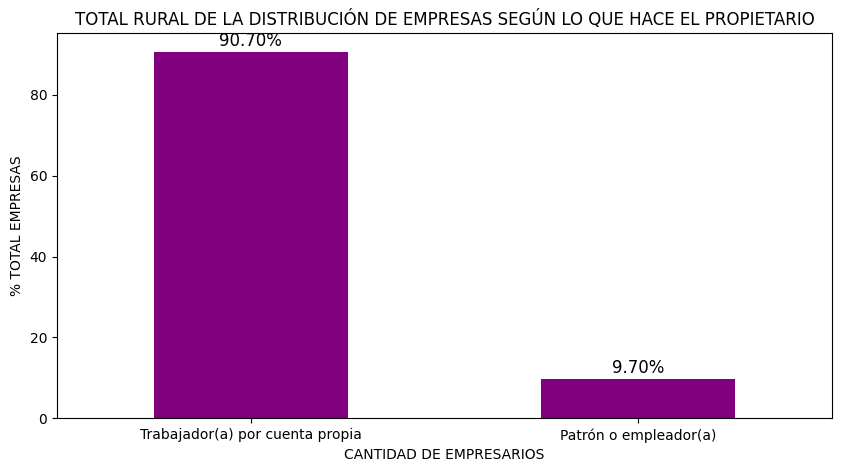

In [49]:
# Convertir a Pandas antes de graficar
df_pandas_cabecera = Procentaje_negocios_por_cabecera.compute()

# Verificar si los datos existen antes de graficar
if not df_pandas_cabecera.empty:
    # Asegurar que la columna "porcentaje_negocios_rurales" sea numérica
    df_pandas_cabecera["porcentaje_negocios_por_cabecerai"] = pd.to_numeric(df_pandas_cabecera["porcentaje_negocios_por_cabecerai"], errors="coerce").fillna(0)

    # Crear el gráfico de barras y guardar el objeto `ax`
    ax = df_pandas_cabecera.plot(
        x="clasificacion",
        y="porcentaje_negocios_por_cabecerai",
        kind="bar",
        figsize=(10, 5),
        legend=False,
        color="purple"
    )

    # Configurar el gráfico
    plt.title("TOTAL RURAL DE LA DISTRIBUCIÓN DE EMPRESAS SEGÚN LO QUE HACE EL PROPIETARIO")
    plt.xlabel("CANTIDAD DE EMPRESARIOS")
    plt.ylabel("% TOTAL EMPRESAS")
    plt.xticks(rotation=0)

    # Agregar etiquetas a cada barra
    for i in range(len(df_pandas_cabecera)):
        plt.text(
            i,  # Posición X
            df_pandas_cabecera["porcentaje_negocios_por_cabecerai"].iloc[i] + 0.5,  # Posición Y
            f"{df_pandas_cabecera['porcentaje_negocios_por_cabecerai'].iloc[i]:.2f}%",  # Convertir a texto con formato
            ha="center", va="bottom", fontsize=12
        )

    # Mostrar el gráfico
    plt.show()

else:
    print("No hay datos para graficar.")

# Cantidad de empresas segun situacion en el empleo del propietario en Centros poblados y rural disperso

In [50]:
CANTIDAD_EMPRESAS_RURAL = context.sql ('''

    SELECT
    SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_RURAL
    FROM df_mi_vi
    WHERE "CLASE_TE_x" = 2
    GROUP BY "CLASE_TE_x"

                                        ''')
CANTIDAD_EMPRESAS_RURAL.compute()

,cantidad_empresas_rural
0,1624378.481


In [51]:
EM_SI_EMP_PRO_rural = context.sql ('''
        SELECT
         SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_RURAL,
        "clas_P3033" AS CLASIFICACION
        FROM df_mi_vi
        WHERE "CLASE_TE_x" = 2
        GROUP BY "clas_P3033"
        ORDER BY 2
                            ''')
EM_SI_EMP_PRO_rural.compute()

,cantidad_empresas_rural,clasificacion
1,150324.723,Patrón o empleador(a)
0,1474053.758,Trabajador(a) por cuenta propia


In [52]:
## mostrando resultado como porcentaje
context.create_table("EM_SI_EMP_PRO_rural",EM_SI_EMP_PRO_rural)

Procentaje_negocios_RURAL = context.sql ('''
        SELECT
        round(("cantidad_empresas_rural"/1528424.769*100),1) as Porcentaje_negocios_Rurales, "clasificacion"
        FROM EM_SI_EMP_PRO_rural
        ORDER BY 1 desc

''')
Procentaje_negocios_RURAL.compute()

,porcentaje_negocios_rurales,clasificacion
0,96.400,Trabajador(a) por cuenta propia
1,9.800,Patrón o empleador(a)


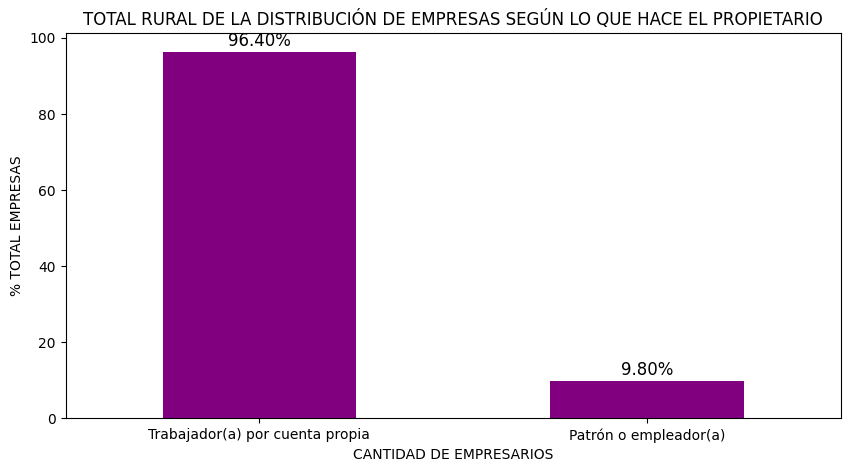

In [53]:
# Convertir a Pandas antes de graficar
df_pandas_rural = Procentaje_negocios_RURAL.compute()

# Verificar si los datos existen antes de graficar
if not df_pandas_rural.empty:
    # Asegurar que la columna "porcentaje_negocios_rurales" sea numérica
    df_pandas_rural["porcentaje_negocios_rurales"] = pd.to_numeric(df_pandas_rural["porcentaje_negocios_rurales"], errors="coerce").fillna(0)

    # Crear el gráfico de barras y guardar el objeto `ax`
    ax = df_pandas_rural.plot(
        x="clasificacion",
        y="porcentaje_negocios_rurales",
        kind="bar",
        figsize=(10, 5),
        legend=False,
        color="purple"
    )

    # Configurar el gráfico
    plt.title("TOTAL RURAL DE LA DISTRIBUCIÓN DE EMPRESAS SEGÚN LO QUE HACE EL PROPIETARIO")
    plt.xlabel("CANTIDAD DE EMPRESARIOS")
    plt.ylabel("% TOTAL EMPRESAS")
    plt.xticks(rotation=0)

    # Agregar etiquetas a cada barra
    for i in range(len(df_pandas_rural)):
        plt.text(
            i,  # Posición X
            df_pandas_rural["porcentaje_negocios_rurales"].iloc[i] + 0.5,  # Posición Y
            f"{df_pandas_rural['porcentaje_negocios_rurales'].iloc[i]:.2f}%",  # Convertir a texto con formato
            ha="center", va="bottom", fontsize=12
        )

    # Mostrar el gráfico
    plt.show()

else:
    print("No hay datos para graficar.")

## TOTAL NACIONAL DE EMPRESAS SEGUN LA SITUACION DE EMPLEO DEL PROPIETARIO DE LA EMPRESA

In [54]:
# TOTAL NACIONAL
TOTAL_NACIONAL = context.sql ('''
        SELECT
         SUM("F_EXP_y") AS TOTAL_PAIS,
        "clas_P3033" AS CLASIFICACION
        FROM df_mi_vi
        GROUP BY "clas_P3033"
        ORDER BY 2
                            ''')
TOTAL_NACIONAL.compute()

,total_pais,clasificacion
1,505195.263,Patrón o empleador(a)
0,4792056.293,Trabajador(a) por cuenta propia


In [55]:
## mostrando resultado como porcentaje
context.create_table("TOTAL_NACIONAL",TOTAL_NACIONAL)

P_TOTAL_NACIONAL = context.sql ('''
        SELECT
        round(("total_pais"/5188402.435524806*100),1) as Porcentaje_TOTAL_NACIONAL, "clasificacion"
        FROM TOTAL_NACIONAL
        ORDER BY 1 desc

''')
P_TOTAL_NACIONAL.compute()

,porcentaje_total_nacional,clasificacion
0,92.400,Trabajador(a) por cuenta propia
1,9.700,Patrón o empleador(a)


In [56]:
import matplotlib.pyplot as plt # nos sirve para hacer graficos

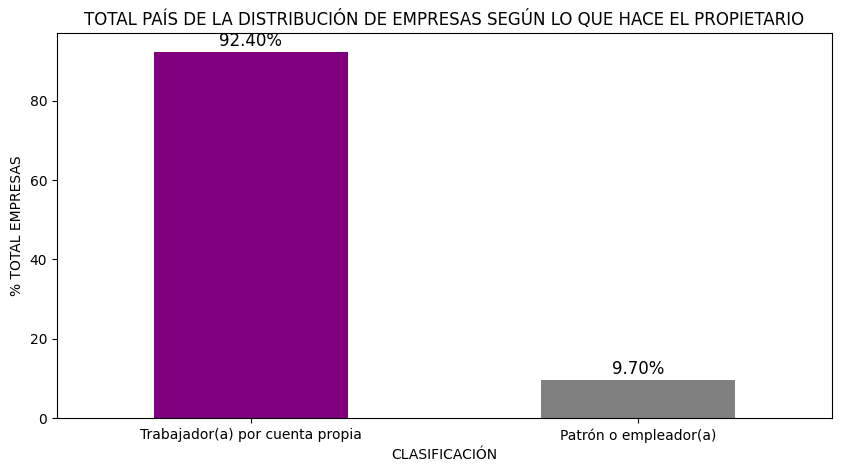

In [57]:
# Convertir a Pandas antes de graficar
df_pandas = P_TOTAL_NACIONAL.compute()

# Definir colores personalizados
colores = {
    "Trabajador(a) por cuenta propia": "purple",
    "Patrón o empleador(a)": "grey"
}

# Verificar si los datos existen antes de graficar
if not df_pandas.empty:
    # Asegurar que la columna "porcentaje_total_nacional" sea numérica
    df_pandas["porcentaje_total_nacional"] = pd.to_numeric(df_pandas["porcentaje_total_nacional"], errors="coerce").fillna(0)

    # Asignar colores según la clasificación
    colores_barras = df_pandas["clasificacion"].map(colores)

    # Crear el gráfico de barras y guardar el objeto `ax`
    ax = df_pandas.plot(
        x="clasificacion",
        y="porcentaje_total_nacional",
        kind="bar",
        figsize=(10, 5),
        legend=False,
        color=colores_barras  # <- Aquí se pasa correctamente la lista de colores
    )

    # Configurar el gráfico
    plt.title("TOTAL PAÍS DE LA DISTRIBUCIÓN DE EMPRESAS SEGÚN LO QUE HACE EL PROPIETARIO")
    plt.xlabel("CLASIFICACIÓN")
    plt.ylabel("% TOTAL EMPRESAS")
    plt.xticks(rotation=0)

    # Agregar etiquetas a cada barra
    for i in range(len(df_pandas)):
        plt.text(
            i,  # Posición X
            df_pandas["porcentaje_total_nacional"].iloc[i] + 0.5,  # Posición Y
            f"{df_pandas['porcentaje_total_nacional'].iloc[i]:.2f}%",  # Convertir a texto con formato
            ha="center", va="bottom", fontsize=12
        )

    # Mostrar el gráfico
    plt.show()

else:
    print("No hay datos para graficar.")

<div style="text-align: center; color: green; font-size: 27px; line-height: 1.5;"> COMPARACION DE LAS TRES GRAFICAS </div>

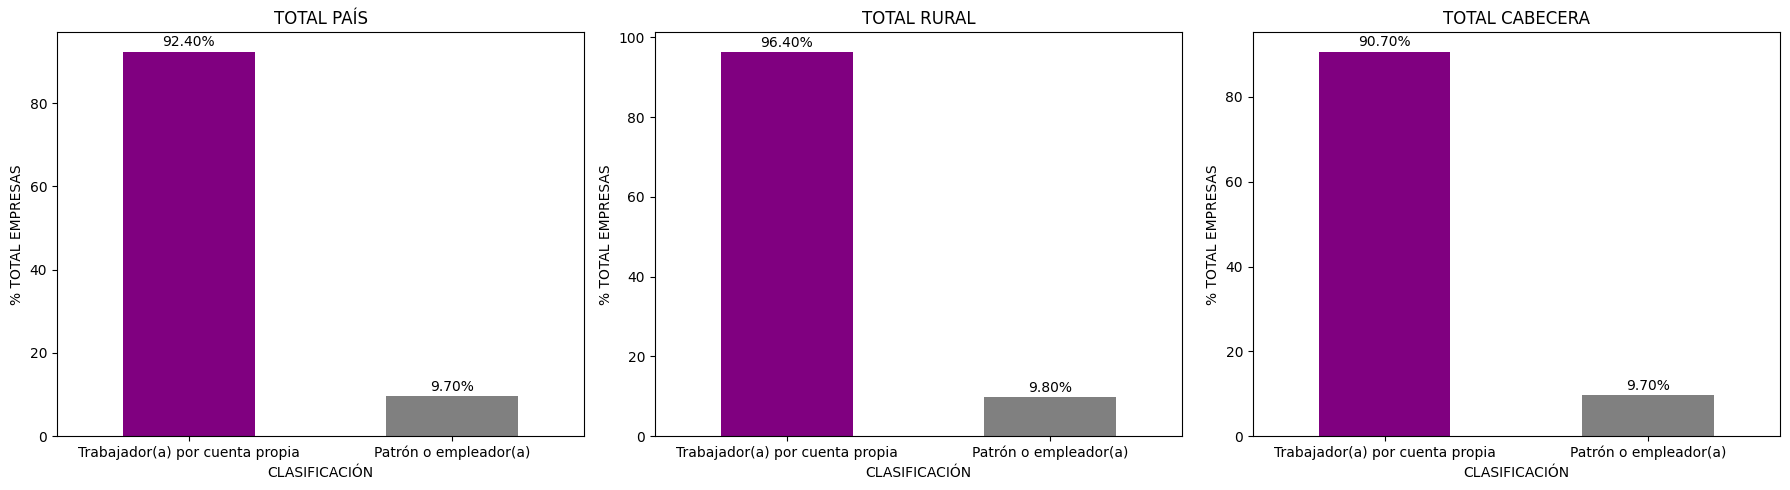

In [58]:
# Convertir a Pandas antes de graficar
df_nacional = P_TOTAL_NACIONAL.compute()
df_rural = Procentaje_negocios_RURAL.compute()
df_cabecera = Procentaje_negocios_por_cabecera.compute()

# Definir colores personalizados
colores = {
    "Trabajador(a) por cuenta propia": "purple",
    "Patrón o empleador(a)": "grey"
}

# Verificar si los datos existen antes de graficar
if not df_nacional.empty and not df_rural.empty and not df_cabecera.empty:

    # Convertir a numérico las columnas de porcentaje
    df_nacional["porcentaje_total_nacional"] = pd.to_numeric(df_nacional["porcentaje_total_nacional"], errors="coerce").fillna(0)
    df_rural["porcentaje_negocios_rurales"] = pd.to_numeric(df_rural["porcentaje_negocios_rurales"], errors="coerce").fillna(0)
    df_cabecera["porcentaje_negocios_por_cabecerai"] = pd.to_numeric(df_cabecera["porcentaje_negocios_por_cabecerai"], errors="coerce").fillna(0)

    # Asignar colores según la clasificación
    colores_nacional = df_nacional["clasificacion"].map(colores)
    colores_rural = df_rural["clasificacion"].map(colores)
    colores_cabecera = df_cabecera["clasificacion"].map(colores)

    # Crear la figura con 3 subgráficos
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfico 1 - Total Nacional
    ax1 = df_nacional.plot(
        x="clasificacion",
        y="porcentaje_total_nacional",
        kind="bar",
        ax=axes[0],
        legend=False,
        color=colores_nacional
    )
    axes[0].set_title("TOTAL PAÍS")
    axes[0].set_xlabel("CLASIFICACIÓN")
    axes[0].set_ylabel("% TOTAL EMPRESAS")
    axes[0].tick_params(axis="x", rotation=0)

    # Agregar etiquetas a cada barra
    for i, valor in enumerate(df_nacional["porcentaje_total_nacional"]):
        axes[0].text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    # Gráfico 2 - Total Rural
    ax2 = df_rural.plot(
        x="clasificacion",
        y="porcentaje_negocios_rurales",
        kind="bar",
        ax=axes[1],
        legend=False,
        color=colores_rural
    )
    axes[1].set_title("TOTAL RURAL")
    axes[1].set_xlabel("CLASIFICACIÓN")
    axes[1].set_ylabel("% TOTAL EMPRESAS")
    axes[1].tick_params(axis="x", rotation=0)

    # Agregar etiquetas a cada barra
    for i, valor in enumerate(df_rural["porcentaje_negocios_rurales"]):
        axes[1].text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    # Gráfico 3 - Total Cabecera
    ax3 = df_cabecera.plot(
        x="clasificacion",
        y="porcentaje_negocios_por_cabecerai",
        kind="bar",
        ax=axes[2],
        legend=False,
        color=colores_cabecera
    )
    axes[2].set_title("TOTAL CABECERA")
    axes[2].set_xlabel("CLASIFICACIÓN")
    axes[2].set_ylabel("% TOTAL EMPRESAS")
    axes[2].tick_params(axis="x", rotation=0)

    # Agregar etiquetas a cada barra
    for i, valor in enumerate(df_cabecera["porcentaje_negocios_por_cabecerai"]):
        axes[2].text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    # Ajustar el diseño
    plt.tight_layout()
    plt.show()

else:
    print("No hay datos suficientes para graficar.")


## <span style="color:blue"> Lo que se busca es tener conocimiento sobre el estado de las microempresas para Armenia-Quindio en el año 2023</span>

## CABECERA MUNICIPAL DE ARMENIA

In [59]:
CANTIDAD_EMPRESAS_ARMENIA = context.sql ('''

    SELECT
    SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_EN_ARMENIA
    FROM df_mi_vi
    WHERE "AREA_x" = 63
    GROUP BY "AREA_x"

                                        ''')
CANTIDAD_EMPRESAS_ARMENIA.compute()

,cantidad_empresas_en_armenia
0,26955.483


In [60]:
CANTIDAD_EMPRESAS_ARMENIA_CABECERA = context.sql ('''

    SELECT
    SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_CABECERA_EN_ARMENIA
    FROM df_mi_vi
    WHERE "CLASE_TE_x" = 1 and "AREA_x" = 63
    GROUP BY "CLASE_TE_x"

                                        ''')
CANTIDAD_EMPRESAS_ARMENIA_CABECERA.compute()

,cantidad_empresas_cabecera_en_armenia
0,26955.483


In [61]:
## que hace el dueño del micronegocio para Armenia
EM_SI_EMP_PRO_CABECERA_ARMENIA = context.sql ('''
        SELECT
         SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_CABECERA_ARMENIA,
        "clas_P3033" AS CLASIFICACION
        FROM df_mi_vi
        WHERE "CLASE_TE_x" = 1 AND "AREA_x" = 63
        GROUP BY "clas_P3033"
        ORDER BY 2
                            ''')
EM_SI_EMP_PRO_CABECERA_ARMENIA.compute()

,cantidad_empresas_cabecera_armenia,clasificacion
1,3364.391,Patrón o empleador(a)
0,23591.092,Trabajador(a) por cuenta propia


In [62]:
## mostrando resultado como porcentaje
context.create_table("EM_SI_EMP_PRO_CABECERA_ARMENIA",EM_SI_EMP_PRO_CABECERA_ARMENIA)

Procentaje_negocios_CABECERA_ARMENIAA = context.sql ('''
        SELECT
        round(("cantidad_empresas_cabecera_armenia"/29154.944*100),1) as Porcentaje_negocios_CABECERA_ARMENIA, "clasificacion"
        FROM EM_SI_EMP_PRO_CABECERA_ARMENIA
        ORDER BY 1 desc

''')
Procentaje_negocios_CABECERA_ARMENIAA.compute()

,porcentaje_negocios_cabecera_armenia,clasificacion
0,80.900,Trabajador(a) por cuenta propia
1,11.500,Patrón o empleador(a)


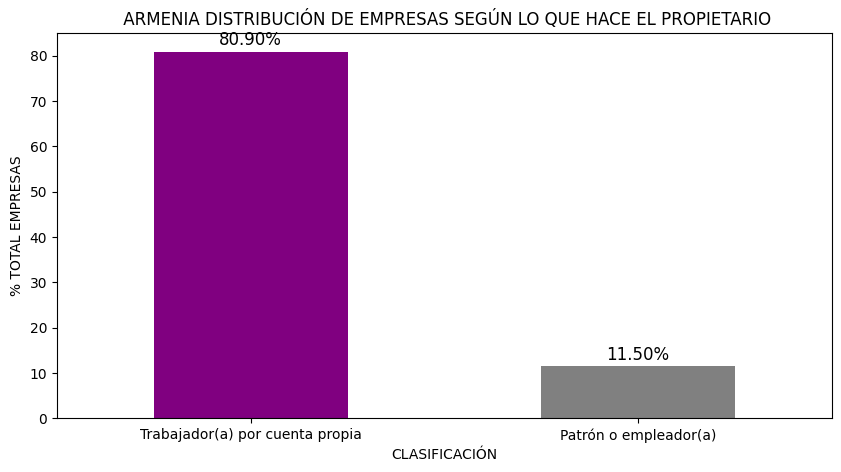

In [63]:
# Convertir a Pandas antes de graficar
df_pandas_armenia = Procentaje_negocios_CABECERA_ARMENIAA.compute()

# Definir colores personalizados
colores = {
    "Trabajador(a) por cuenta propia": "purple",
    "Patrón o empleador(a)": "grey"
}

# Verificar si los datos existen antes de graficar
if not df_pandas_armenia.empty:
    # Asegurar que la columna "porcentaje_total_nacional" sea numérica
    df_pandas_armenia["porcentaje_negocios_cabecera_armenia"] = pd.to_numeric(df_pandas_armenia["porcentaje_negocios_cabecera_armenia"], errors="coerce").fillna(0)

    # Asignar colores según la clasificación
    colores_barras = df_pandas["clasificacion"].map(colores)

    # Crear el gráfico de barras y guardar el objeto `ax`
    ax = df_pandas_armenia.plot(
        x="clasificacion",
        y="porcentaje_negocios_cabecera_armenia",
        kind="bar",
        figsize=(10, 5),
        legend=False,
        color=colores_barras  # <- Aquí se pasa correctamente la lista de colores
    )

    # Configurar el gráfico
    plt.title(" ARMENIA DISTRIBUCIÓN DE EMPRESAS SEGÚN LO QUE HACE EL PROPIETARIO")
    plt.xlabel("CLASIFICACIÓN")
    plt.ylabel("% TOTAL EMPRESAS")
    plt.xticks(rotation=0)

    # Agregar etiquetas a cada barra
    for i in range(len(df_pandas)):
        plt.text(
            i,  # Posición X
            df_pandas_armenia["porcentaje_negocios_cabecera_armenia"].iloc[i] + 0.5,  # Posición Y
            f"{df_pandas_armenia['porcentaje_negocios_cabecera_armenia'].iloc[i]:.2f}%",  # Convertir a texto con formato
            ha="center", va="bottom", fontsize=12
        )

    # Mostrar el gráfico
    plt.show()

else:
    print("No hay datos para graficar.")

## RURAL DE ARMENIA

In [64]:
CANTIDAD_EMPRESAS_ARMENIA_RURAL = context.sql('''
    SELECT
        SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_RURAL_EN_ARMENIA
    FROM df_mi_vi
    WHERE "CLASE_TE_x" = 2 AND "AREA_x" = 63
    GROUP BY "CLASE_TE_x"
''')

# Verificar si el resultado no es None antes de llamar compute()
if CANTIDAD_EMPRESAS_ARMENIA_RURAL is not None:
    resultado = CANTIDAD_EMPRESAS_ARMENIA_RURAL.compute()
    print(resultado)
else:
    print("Error: La consulta SQL no devolvió ningún resultado.")


Empty DataFrame
Columns: [cantidad_empresas_rural_en_armenia]
Index: []


## los propietarios son hombres o mujeres

In [65]:
df_mi_vi.compute().head(2)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033,P_HOM_MUJ
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,44.000,NaN,60.051,198887306.438,La Guajira,NO_HAY_UNA_MONDA,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia,MUJER
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,44.000,NaN,86.341,828874319.722,La Guajira,NO_HAY_UNA_MONDA,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia,HOMBRE


In [66]:
 ## TOTAL PROPIETARIOS (HOMBRES) ARMENIA
SEXO_PROPIETARIO_HOMBRE = context.sql ('''
SELECT
    "P_HOM_MUJ" AS HOMBRES_O_MUJER,
    "CUIDAD_PRINCIPAL",
    SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_CABECERA_ARMENIA
FROM df_mi_vi
WHERE "AREA_x" = 63 AND "P35" = 1
GROUP BY "P_HOM_MUJ", "CUIDAD_PRINCIPAL"
ORDER BY "CUIDAD_PRINCIPAL"
                           ''')
SEXO_PROPIETARIO_HOMBRE.compute()

,hombres_o_mujer,CUIDAD_PRINCIPAL,cantidad_empresas_cabecera_armenia
0,HOMBRE,Armenia,15661.614


In [67]:
## CUAL ES EL SEXO DEL PROPIETARIO DEL NOGOCIO PARA ARMENIA
SEXO_PROPIETARIO = context.sql ('''
SELECT
    "P_HOM_MUJ" AS HOMBRE,
    "clas_P3033" AS CLASIFICACION,
    SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_CABECERA_ARMENIA_SEXO
FROM df_mi_vi
WHERE  "AREA_x" = 63
    AND "P35" = 1
GROUP BY "P_HOM_MUJ", "clas_P3033"
ORDER BY CLASIFICACION
                            ''')
SEXO_PROPIETARIO.compute()

,hombre,clasificacion,cantidad_empresas_cabecera_armenia_sexo
1,HOMBRE,Patrón o empleador(a),2462.963
0,HOMBRE,Trabajador(a) por cuenta propia,13198.651


In [68]:
## mostrando resultado como porcentaje
context.create_table("SEXO_PROPIETARIO",SEXO_PROPIETARIO)

Procentaje_SEXO_PROPIETARIO = context.sql ('''
        SELECT
        round(("cantidad_empresas_cabecera_armenia_sexo"/17580.255*100),1) as Porcentaje_negocios_CABECERA_ARMENIA_HOMBRES,
        "clasificacion"
        FROM SEXO_PROPIETARIO
        GROUP BY "hombre", "clasificacion", "cantidad_empresas_cabecera_armenia_sexo"
        ORDER BY hombre desc



''')
Procentaje_SEXO_PROPIETARIO.compute()

,porcentaje_negocios_cabecera_armenia_hombres,clasificacion
0,14.000,Patrón o empleador(a)
1,75.100,Trabajador(a) por cuenta propia


# MUJER

In [69]:
 ## TOTAL PROPIETARIOS ARMENIA
SEXO_PROPIETARIO_MUJER = context.sql ('''
SELECT
    "P_HOM_MUJ" AS HOMBRES_O_MUJER,
    "CUIDAD_PRINCIPAL",
    SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_CABECERA_ARMENIA
FROM df_mi_vi
WHERE "AREA_x" = 63 AND "P35" = 2
GROUP BY "P_HOM_MUJ", "CUIDAD_PRINCIPAL"
ORDER BY "CUIDAD_PRINCIPAL"
                           ''')
SEXO_PROPIETARIO_MUJER.compute()

,hombres_o_mujer,CUIDAD_PRINCIPAL,cantidad_empresas_cabecera_armenia
0,MUJER,Armenia,11293.869


In [70]:
## CUAL ES EL SEXO DEL PROPIETARIO DEL NOGOCIO PARA ARMENIA
SEXO_PROPIETARIO = context.sql ('''
SELECT
    "P_HOM_MUJ" AS MUJER,
    "clas_P3033" AS CLASIFICACION,
    SUM("F_EXP_y") AS CANTIDAD_EMPRESAS_CABECERA_ARMENIA_SEXO
FROM df_mi_vi
WHERE "AREA_x" = 63
    AND "P35" = 2
GROUP BY "P_HOM_MUJ", "clas_P3033"
ORDER BY CLASIFICACION
                            ''')
SEXO_PROPIETARIO.compute()

,mujer,clasificacion,cantidad_empresas_cabecera_armenia_sexo
1,MUJER,Patrón o empleador(a),901.428
0,MUJER,Trabajador(a) por cuenta propia,10392.441


In [71]:
## mostrando resultado como porcentaje
context.create_table("SEXO_PROPIETARIO",SEXO_PROPIETARIO)

Procentaje_SEXO_PROPIETARIO_M = context.sql ('''
        SELECT
        round(("cantidad_empresas_cabecera_armenia_sexo"/11574.689*100),1) as Porcentaje_negocios_CABECERA_ARMENIA_MUJERES,
        "clasificacion"
        FROM SEXO_PROPIETARIO
        GROUP BY "mujer", "clasificacion", "cantidad_empresas_cabecera_armenia_sexo"
        ORDER BY mujer desc



''')
Procentaje_SEXO_PROPIETARIO_M.compute()

,porcentaje_negocios_cabecera_armenia_mujeres,clasificacion
0,7.800,Patrón o empleador(a)
1,89.800,Trabajador(a) por cuenta propia


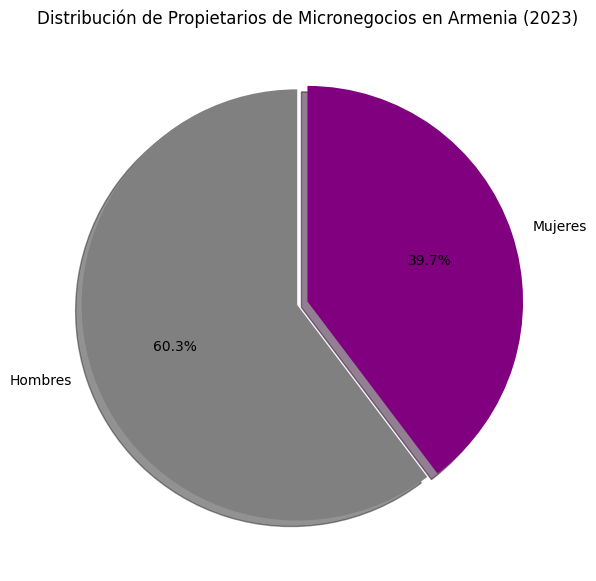

In [72]:
# Datos
labels = ["Hombres", "Mujeres"]
sizes = [17580.255, 11574.689]
colors = ["grey", "purple"]
explode = (0.05, 0)  # Resaltar la sección de Hombres

# Crear gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, explode=explode, startangle=90, shadow=True)
plt.title("Distribución de Propietarios de Micronegocios en Armenia (2023)")
plt.show()

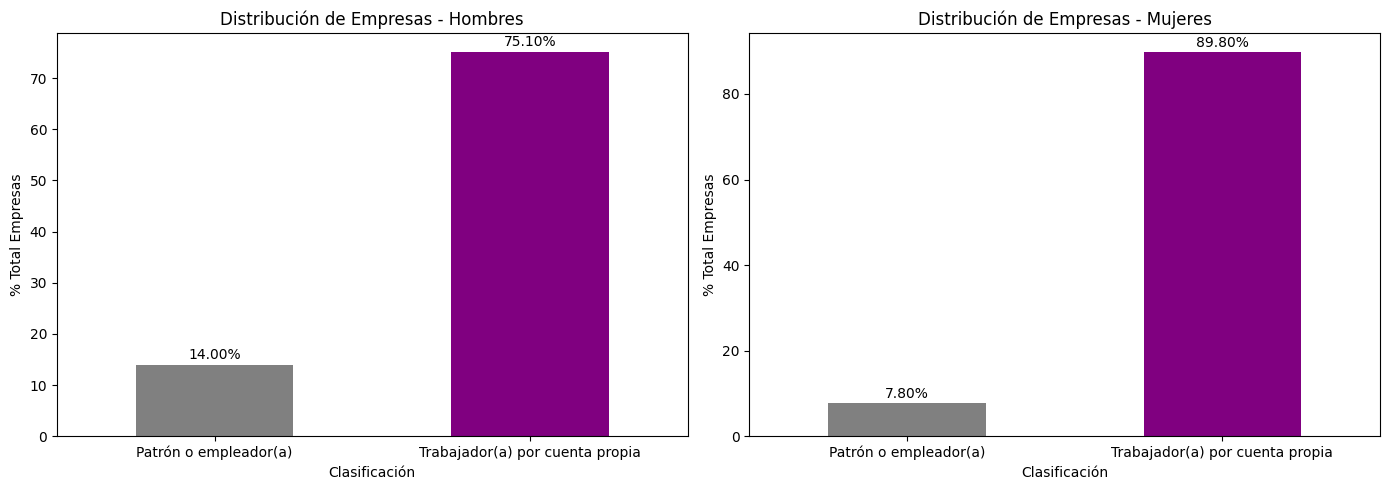

In [73]:
# Convertir a Pandas antes de graficar
df_hombre = Procentaje_SEXO_PROPIETARIO.compute()
df_mujer = Procentaje_SEXO_PROPIETARIO_M.compute()

# Definir colores personalizados
colores = {
    "Trabajador(a) por cuenta propia": "purple",
    "Patrón o empleador(a)": "grey"
}

# Verificar si los datos existen antes de graficar
if not df_hombre.empty and not df_mujer.empty:

    # Convertir a numérico las columnas de porcentaje
    df_hombre["porcentaje_negocios_cabecera_armenia_hombres"] = pd.to_numeric(
        df_hombre["porcentaje_negocios_cabecera_armenia_hombres"], errors="coerce"
    ).fillna(0)

    df_mujer["porcentaje_negocios_cabecera_armenia_mujeres"] = pd.to_numeric(
        df_mujer["porcentaje_negocios_cabecera_armenia_mujeres"], errors="coerce"
    ).fillna(0)

    # Crear listas de colores sin modificar los DataFrames originales
    colores_hombre = df_hombre["clasificacion"].map(colores).fillna("blue")
    colores_mujer = df_mujer["clasificacion"].map(colores).fillna("red")

    # Crear la figura con 2 subgráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1 - Porcentaje de Hombres
    df_hombre.plot(
        x="clasificacion",
        y="porcentaje_negocios_cabecera_armenia_hombres",
        kind="bar",
        ax=axes[0],
        legend=False,
        color=colores_hombre
    )
    axes[0].set_title("Distribución de Empresas - Hombres")
    axes[0].set_xlabel("Clasificación")
    axes[0].set_ylabel("% Total Empresas")
    axes[0].tick_params(axis="x", rotation=0)

    # Agregar etiquetas a cada barra
    for i, valor in enumerate(df_hombre["porcentaje_negocios_cabecera_armenia_hombres"]):
        axes[0].text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    # Gráfico 2 - Porcentaje de Mujeres
    df_mujer.plot(
        x="clasificacion",
        y="porcentaje_negocios_cabecera_armenia_mujeres",
        kind="bar",
        ax=axes[1],
        legend=False,
        color=colores_mujer
    )
    axes[1].set_title("Distribución de Empresas - Mujeres")
    axes[1].set_xlabel("Clasificación")
    axes[1].set_ylabel("% Total Empresas")
    axes[1].tick_params(axis="x", rotation=0)

    # Agregar etiquetas a cada barra
    for i, valor in enumerate(df_mujer["porcentaje_negocios_cabecera_armenia_mujeres"]):
        axes[1].text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    # Ajustar el diseño
    plt.tight_layout()
    plt.show()

else:
    print("No hay datos suficientes para graficar.")


En el total de propietarios de micronegocios en Armenia, se observa que las mujeres tienen una representación de 11.574.689 lo que representael 39.7% del total de micronegocios, mientras que los hombres alcanzan 17.580.255 lo que da un 60.3% de participacion, lo que indica una mayor participación masculina. Sin embargo, al profundizar en los datos, se encuentra que el 91,8% de las mujeres que poseen un micronegocio son trabajadoras, en comparación con el 90,1% de los hombres. Por otro lado, al analizar el porcentaje de patrones con micronegocios, los hombres presentan un 9,90%, mientras que en las mujeres es del 8,20%.

Esto sugiere que, en la capital del Quindío, para el año 2023, las mujeres mostraron un mayor espíritu emprendedor que los hombres, destacándose en la creación y gestión de micronegocios.

## VALOR AGREGADO POR SECTOR PARA LA CIUDAD DE ARMENIA

In [74]:
df_mi_vi.compute().head(2)

,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,COD_DEPTO_x,AREA_x,CLASE_TE_x,P35,P241,MES_REF,P3031,...,COD_DEPTO_y,AREA_y,F_EXP_y,VALOR_AGREGADO_ANUAL,map_departa,CUIDAD_PRINCIPAL,nombre_grupo,map_ubi,clas_P3033,P_HOM_MUJ
0,7627444.000,1.000,1.000,44.000,NaN,2.000,2.000,33.000,ENERO,2.000,...,44.000,NaN,60.051,198887306.438,La Guajira,NO_HAY_UNA_MONDA,Industria manufacturera,Centros poblados y rural disperso,Trabajador(a) por cuenta propia,MUJER
1,7627446.000,1.000,1.000,44.000,NaN,2.000,1.000,31.000,ENERO,2.000,...,44.000,NaN,86.341,828874319.722,La Guajira,NO_HAY_UNA_MONDA,"Agricultura, ganadería, caza, silvicultura y p...",Centros poblados y rural disperso,Trabajador(a) por cuenta propia,HOMBRE


## EL TOTAL DEL VALOR AGREGADO

In [75]:
print (f"El total del valor agregado de todos lo micronegocios para el año 2023 en colombia fue de: {df_vi['VALOR_AGREGADO_ANUAL'].compute().sum()}, \nmientras el valor agregado para armenia fue de 430328006100.301, para tener una referecnia \nse va a comprar Armenia con una cuidad cercana como lo es Pereira la cual tiene un valor agregado de 690155717718.333 ")

El total del valor agregado de todos lo micronegocios para el año 2023 en colombia fue de: 86755643636700.19, 
mientras el valor agregado para armenia fue de 430328006100.301, para tener una referecnia 
se va a comprar Armenia con una cuidad cercana como lo es Pereira la cual tiene un valor agregado de 690155717718.333 


In [76]:
CANTIDAD_EMPRESAS_pereira  = context.sql ('''

    SELECT
    SUM("F_EXP_x") AS CANTIDAD_EMPRESAS_EN_pereira
    FROM df_mi_vi
    WHERE "AREA_x" = 66
    GROUP BY "AREA_x"

                                        ''')
CANTIDAD_EMPRESAS_pereira.compute()

,cantidad_empresas_en_pereira
0,42931.356


In [77]:
## VAMOS A VER EL VALOR AGREGADO DE CADA SECTOR SEGUN LA EMPRESA PARA PEREIRA
VALOR_CIIU_A_T = context.sql(
    '''
    SELECT SUM("VALOR_AGREGADO_ANUAL") AS VALOR_AGREGADO_POR_CIIU_PARA_PEREIRA
    FROM df_mi_vi
    WHERE "AREA_x" = 66
    GROUP BY "AREA_x"
    '''
)
VALOR_CIIU_A_T.compute()

,valor_agregado_por_ciiu_para_pereira
0,853529950047.844


In [78]:
## VAMOS A VER EL VALOR AGREGADO DE CADA SECTOR SEGUN LA EMPRESA PARA ARMEIA
VALOR_CIIU_A_T = context.sql(
    '''
    SELECT SUM("VALOR_AGREGADO_ANUAL") AS VALOR_AGREGADO_POR_CIIU_PARA_ARMENIA
    FROM df_mi_vi
    WHERE "AREA_x" = 63
    GROUP BY "AREA_x"
    '''
)
VALOR_CIIU_A_T.compute()

,valor_agregado_por_ciiu_para_armenia
0,486129360712.994


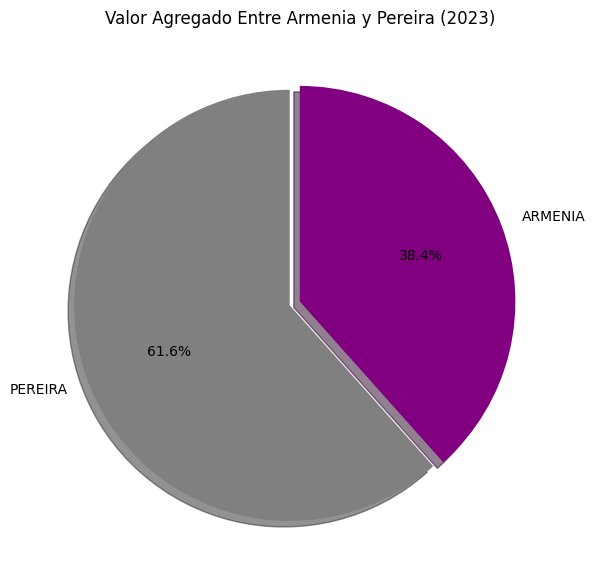

In [79]:
# Datos
labels = ["PEREIRA", "ARMENIA"]
sizes = [690155717718.333, 430328006100.301]
colors = ["grey", "purple"]
explode = (0.05, 0)  # Resaltar la sección de Hombres

# Crear gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, explode=explode, startangle=90, shadow=True)
plt.title("Valor Agregado Entre Armenia y Pereira (2023)")
plt.show()

In [80]:
VALOR_CIIU_ARMENIA = context.sql(
    '''
    SELECT SUM("VALOR_AGREGADO_ANUAL") AS VALOR_AGREGADO_POR_CIIU, "nombre_grupo"
    FROM df_mi_vi
    WHERE "AREA_x" = 63
    GROUP BY "nombre_grupo"
    ORDER BY VALOR_AGREGADO_POR_CIIU desc
    LIMIT 5
    '''
)
VALOR_CIIU_ARMENIA.compute()

,valor_agregado_por_ciiu,nombre_grupo
4,160279994373.435,Comercio y reparación de vehículos automotores...
7,67592411950.381,"Actividades inmobiliarias, profesionales y ser..."
1,53152143696.922,Alojamiento y servicios de comida
0,45403435953.884,Industria manufacturera
2,44957945418.300,"Actividades artísticas, de entretenimiento, de..."
